In [1]:
import numpy as np
import pandas as pd
import os
import gc
import warnings
warnings.filterwarnings('ignore')
from pyproj import Transformer

In [2]:
# ---- CREATE OUTPUT FOLDER ----
output_folder = r"D:\\Important\\Semester\\Semester X\\MTP\\data&results"
os.makedirs(output_folder, exist_ok=True)
print(f"Output folder: {output_folder}")

# ---- PATHS ----
full_data_path = r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\shimla_dataset.parquet"
subsampled_spatial_path = r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\shimla_subsampled_spatial.parquet"
reference_raster = r"D:\\Important\\Semester\\Semester X\\MTP\\Raw data\\landslide_distance.tif"

Output folder: D:\\Important\\Semester\\Semester X\\MTP\\data&results


In [ ]:
# ---- APPROXIMATE BOUNDING BOX FROM PAPER (Lat/Long) ----
# Estimated from Figure 3 axis labels and Figure 4 LSI map
lat_min = 31.03   # south boundary
lat_max = 31.14   # north boundary
lon_min = 77.08   # west boundary
lon_max = 77.24   # east boundary

print(f"\nApproximate bounding box (WGS84):")
print(f"  Latitude:  {lat_min}°N to {lat_max}°N")
print(f"  Longitude: {lon_min}°E to {lon_max}°E")

# ---- CONVERT TO UTM (EPSG:32643) ----
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32643", always_xy=True)

# Convert corners (lon, lat) → (easting, northing)
utm_west, utm_south = transformer.transform(lon_min, lat_min)
utm_east, utm_north = transformer.transform(lon_max, lat_max)

print(f"\nConverted bounding box (UTM 43N):")
print(f"  Easting:  {utm_west:.2f} to {utm_east:.2f}")
print(f"  Northing: {utm_south:.2f} to {utm_north:.2f}")

# ---- COMPUTE AREA ----
width_m = utm_east - utm_west
height_m = utm_north - utm_south
area_sqm = width_m * height_m
area_sqkm = area_sqm / 1_000_000

print(f"\nBox dimensions:")
print(f"  Width:  {width_m:.2f} m ({width_m/1000:.2f} km)")
print(f"  Height: {height_m:.2f} m ({height_m/1000:.2f} km)")
print(f"  Area:   {area_sqkm:.2f} sq.km")
print(f"  Target: 124 sq.km")
print(f"  Difference: {area_sqkm - 124:.2f} sq.km ({((area_sqkm/124)-1)*100:+.1f}%)")

# ---- GET RASTER TRANSFORM FOR PIXEL MAPPING ----
import rasterio
with rasterio.open(reference_raster) as src:
    raster_transform = src.transform
    raster_crs = src.crs
    raster_width = src.width
    raster_height = src.height

# Convert UTM bounds to pixel row/col
# transform: pixel_col → easting, pixel_row → northing
col_min = int((utm_west - raster_transform.c) / raster_transform.a)
col_max = int((utm_east - raster_transform.c) / raster_transform.a)
row_min = int((utm_north - raster_transform.f) / raster_transform.e)  # negative e
row_max = int((utm_south - raster_transform.f) / raster_transform.e)

# Clamp to raster bounds
col_min = max(0, col_min)
col_max = min(raster_width - 1, col_max)
row_min = max(0, row_min)
row_max = min(raster_height - 1, row_max)

print(f"\nPixel bounds in raster:")
print(f"  Row: {row_min} to {row_max} ({row_max - row_min} pixels)")
print(f"  Col: {col_min} to {col_max} ({col_max - col_min} pixels)")

expected_pixels = (row_max - row_min) * (col_max - col_min)
print(f"  Expected pixels in box: {expected_pixels:,}")
print(f"  Expected area from pixels: {expected_pixels * 100 / 1_000_000:.2f} sq.km")


Approximate bounding box (WGS84):
  Latitude:  31.036°N to 31.14°N
  Longitude: 77.08°E to 77.23°E

Converted bounding box (UTM 43N):
  Easting:  698515.35 to 712602.82
  Northing: 3435449.95 to 3447257.84

Box dimensions:
  Width:  14087.47 m (14.09 km)
  Height: 11807.88 m (11.81 km)
  Area:   166.34 sq.km
  Target: 124 sq.km
  Difference: 42.34 sq.km (+34.1%)

Pixel bounds in raster:
  Row: 6484 to 7665 (1181 pixels)
  Col: 850 to 2259 (1409 pixels)
  Expected pixels in box: 1,664,029
  Expected area from pixels: 166.40 sq.km


In [5]:
# ---- ADJUST BOUNDING BOX ----
# Current area: 187.74 sq.km, Target: 124 sq.km
# Scale factor: sqrt(124 / 187.74) = 0.8126
# Shrink both dimensions proportionally from center

scale = np.sqrt(124.0 / area_sqkm)
print(f"Scale factor: {scale:.4f}")

# Current center
lat_center = (lat_min + lat_max) / 2
lon_center = (lon_min + lon_max) / 2

# Current half-ranges
lat_half = (lat_max - lat_min) / 2
lon_half = (lon_max - lon_min) / 2

# Scaled half-ranges
lat_half_new = lat_half * scale
lon_half_new = lon_half * scale

# New bounds
lat_min_adj = lat_center - lat_half_new
lat_max_adj = lat_center + lat_half_new
lon_min_adj = lon_center - lon_half_new
lon_max_adj = lon_center + lon_half_new

print(f"\nAdjusted bounding box (WGS84):")
print(f"  Latitude:  {lat_min_adj:.4f}°N to {lat_max_adj:.4f}°N")
print(f"  Longitude: {lon_min_adj:.4f}°E to {lon_max_adj:.4f}°E")

# ---- CONVERT TO UTM ----
utm_west_adj, utm_south_adj = transformer.transform(lon_min_adj, lat_min_adj)
utm_east_adj, utm_north_adj = transformer.transform(lon_max_adj, lat_max_adj)

width_adj = utm_east_adj - utm_west_adj
height_adj = utm_north_adj - utm_south_adj
area_adj = (width_adj * height_adj) / 1_000_000

print(f"\nConverted bounding box (UTM 43N):")
print(f"  Easting:  {utm_west_adj:.2f} to {utm_east_adj:.2f}")
print(f"  Northing: {utm_south_adj:.2f} to {utm_north_adj:.2f}")
print(f"\nAdjusted dimensions:")
print(f"  Width:  {width_adj:.2f} m ({width_adj/1000:.2f} km)")
print(f"  Height: {height_adj:.2f} m ({height_adj/1000:.2f} km)")
print(f"  Area:   {area_adj:.2f} sq.km")
print(f"  Target: 124 sq.km")
print(f"  Difference: {area_adj - 124:.2f} sq.km ({((area_adj/124)-1)*100:+.1f}%)")

# ---- CONVERT TO PIXEL BOUNDS ----
col_min_adj = int((utm_west_adj - raster_transform.c) / raster_transform.a)
col_max_adj = int((utm_east_adj - raster_transform.c) / raster_transform.a)
row_min_adj = int((utm_north_adj - raster_transform.f) / raster_transform.e)
row_max_adj = int((utm_south_adj - raster_transform.f) / raster_transform.e)

col_min_adj = max(0, col_min_adj)
col_max_adj = min(raster_width - 1, col_max_adj)
row_min_adj = max(0, row_min_adj)
row_max_adj = min(raster_height - 1, row_max_adj)

expected_pixels_adj = (row_max_adj - row_min_adj) * (col_max_adj - col_min_adj)

print(f"\nPixel bounds in raster:")
print(f"  Row: {row_min_adj} to {row_max_adj} ({row_max_adj - row_min_adj} pixels)")
print(f"  Col: {col_min_adj} to {col_max_adj} ({col_max_adj - col_min_adj} pixels)")
print(f"  Pixels in box: {expected_pixels_adj:,}")
print(f"  Area from pixels: {expected_pixels_adj * 100 / 1_000_000:.2f} sq.km")

# ---- STORE FINAL BOUNDS ----
box_row_min = row_min_adj
box_row_max = row_max_adj
box_col_min = col_min_adj
box_col_max = col_max_adj

Scale factor: 0.8634

Adjusted bounding box (WGS84):
  Latitude:  31.0431°N to 31.1329°N
  Longitude: 77.0902°E to 77.2198°E

Converted bounding box (UTM 43N):
  Easting:  699478.57 to 711641.58
  Northing: 3436255.82 to 3446450.66

Adjusted dimensions:
  Width:  12163.02 m (12.16 km)
  Height: 10194.84 m (10.19 km)
  Area:   124.00 sq.km
  Target: 124 sq.km
  Difference: -0.00 sq.km (-0.0%)

Pixel bounds in raster:
  Row: 6565 to 7584 (1019 pixels)
  Col: 946 to 2163 (1217 pixels)
  Pixels in box: 1,240,123
  Area from pixels: 124.01 sq.km


In [6]:
# ---- LOAD FULL DATASET ----
print("Loading full dataset...")
df_full = pd.read_parquet(full_data_path)
df_full["lulc"] = df_full["lulc"].astype(np.int8)
print(f"Full dataset: {df_full.shape}")

# ---- FILTER TO BOX REGION ----
print(f"\nFiltering to box region (rows {box_row_min}-{box_row_max}, cols {box_col_min}-{box_col_max})...")

mask = (
    (df_full["pixel_row"] >= box_row_min) & (df_full["pixel_row"] <= box_row_max) &
    (df_full["pixel_col"] >= box_col_min) & (df_full["pixel_col"] <= box_col_max)
)

df_box = df_full[mask].copy().reset_index(drop=True)

print(f"Pixels in box: {len(df_box):,}")
print(f"Area covered: {len(df_box) * 100 / 1_000_000:.2f} sq.km")
print(f"Memory: {df_box.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

# ---- CLASS DISTRIBUTION IN BOX ----
feature_cols = ["landslide_dist", "slope", "lulc", "elevation", "road_dist",
                "builtup_dist", "land_value", "water_dist", "lineament_dist",
                "lst", "railway_dist"]
class_labels = {1: "Very Low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very High"}

print(f"\nClass distribution in box region:")
print(f"  {'Class':<12} {'Count':>10} {'Percentage':>10}")
print("  " + "-" * 35)
counts = df_box["lsi_classified"].value_counts().sort_index()
for cls, count in counts.items():
    pct = (count / len(df_box)) * 100
    print(f"  {int(cls)} {class_labels[int(cls)]:<10} {count:>10,} {pct:>9.2f}%")

# ---- FREE FULL DATASET ----
del df_full
gc.collect()

# ---- SAVE BOX DATASET ----
box_path = os.path.join(output_folder, "shimla_box_124sqkm.parquet")
df_box.to_parquet(box_path, index=False, engine="pyarrow")
print(f"\nSaved: {box_path}")
print(f"File size: {os.path.getsize(box_path) / (1024**2):.1f} MB")

Loading full dataset...
Full dataset: (51423700, 15)

Filtering to box region (rows 6565-7584, cols 946-2163)...
Pixels in box: 1,239,717
Area covered: 123.97 sq.km
Memory: 67.4 MB

Class distribution in box region:
  Class             Count Percentage
  -----------------------------------
  1 Very Low       92,839      7.49%
  2 Low           380,367     30.68%
  3 Moderate      699,562     56.43%
  4 High           66,949      5.40%

Saved: D:\\Important\\Semester\\Semester X\\MTP\\data&results\shimla_box_124sqkm.parquet
File size: 37.7 MB


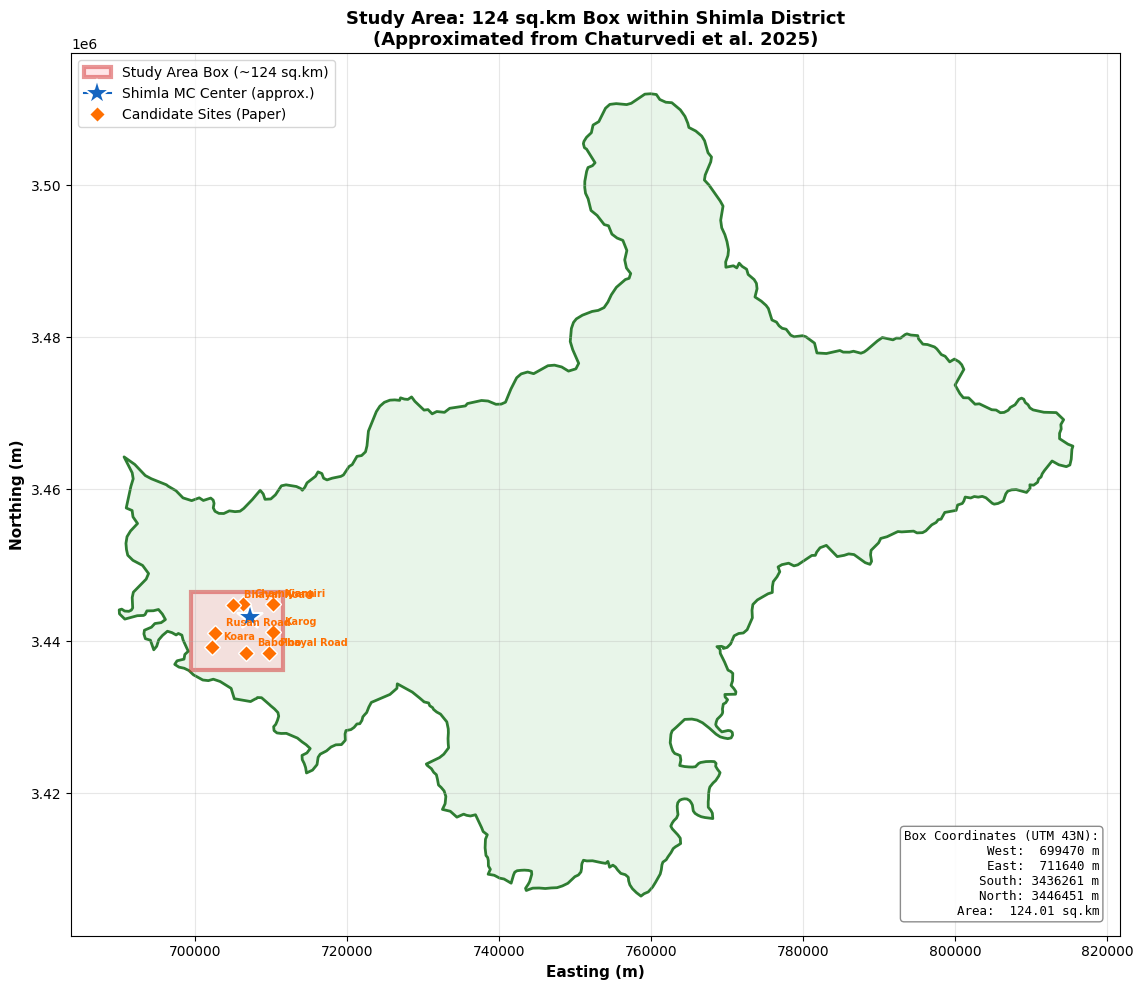

✓ Saved: study_area_box_visualization.png


In [7]:
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.patches import Rectangle

# ---- LOAD SHAPEFILE ----
shapefile_path = r"D:\\Important\\Semester\\Semester X\\MTP\\DATA\\shimla shp\\shimla_boundary_utm.shp"
shimla = gpd.read_file(shapefile_path)

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(12, 10))

# District boundary
shimla.plot(ax=ax, facecolor="#E8F5E9", edgecolor="#2E7D32", linewidth=2, label="Shimla District")

# Box region
box_left = raster_transform.c + (box_col_min * raster_transform.a)
box_right = raster_transform.c + (box_col_max * raster_transform.a)
box_top = raster_transform.f + (box_row_min * raster_transform.e)
box_bottom = raster_transform.f + (box_row_max * raster_transform.e)

box_width = box_right - box_left
box_height = box_top - box_bottom

rect = Rectangle((box_left, box_bottom), box_width, box_height,
                  linewidth=3, edgecolor="#D32F2F", facecolor="#FFCDD2", alpha=0.5,
                  label=f"Study Area Box (~124 sq.km)")
ax.add_patch(rect)

# Approximate MC center point
mc_easting, mc_northing = transformer.transform(77.1734, 31.1048)
ax.plot(mc_easting, mc_northing, marker='*', color='#1565C0', markersize=20,
        markeredgecolor='white', markeredgewidth=1.5, label="Shimla MC Center (approx.)")

# Candidate sites from paper (Table 11)
sites = {
    "Baboloo": (77.167, 31.062),
    "Chamiyana": (77.164, 31.12),
    "Rusan Road": (77.124, 31.086),
    "Koara": (77.12, 31.07),
    "Phayal Road": (77.199, 31.061),
    "Bhayal Road": (77.15, 31.119),
    "Karog": (77.205, 31.086),
    "Kiargiri": (77.205, 31.119)
}

for name, (lon, lat) in sites.items():
    e, n = transformer.transform(lon, lat)
    ax.plot(e, n, marker='D', color='#FF6F00', markersize=8,
            markeredgecolor='white', markeredgewidth=1)
    ax.annotate(name, (e, n), textcoords="offset points", xytext=(8, 5),
                fontsize=7, color='#FF6F00', fontweight='bold')

# Add first site to legend
ax.plot([], [], marker='D', color='#FF6F00', markersize=8,
        markeredgecolor='white', linestyle='None', label="Candidate Sites (Paper)")

# Labels
ax.set_xlabel("Easting (m)", fontsize=11, fontweight="bold")
ax.set_ylabel("Northing (m)", fontsize=11, fontweight="bold")
ax.set_title("Study Area: 124 sq.km Box within Shimla District\n(Approximated from Chaturvedi et al. 2025)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)

# Add box coordinates as text
textstr = (f"Box Coordinates (UTM 43N):\n"
           f"  West:  {box_left:.0f} m\n"
           f"  East:  {box_right:.0f} m\n"
           f"  South: {box_bottom:.0f} m\n"
           f"  North: {box_top:.0f} m\n"
           f"  Area:  124.01 sq.km")
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=props, fontfamily='monospace')

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "study_area_box_visualization.png"), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: study_area_box_visualization.png")

In [9]:
# ---- CHECK LSI DISTRIBUTION NEAR CLASS 5 BOUNDARY ----
print("LSI distribution in box region:")
print(f"  Min: {df_box['lsi_continuous'].min():.4f}")
print(f"  Max: {df_box['lsi_continuous'].max():.4f}")
print(f"  Mean: {df_box['lsi_continuous'].mean():.4f}")

print(f"\nPixels near Class 5 threshold (LSI > 4.0):")
above_4 = df_box[df_box["lsi_continuous"] > 4.0]
print(f"  LSI > 4.0: {len(above_4):,}")
print(f"  LSI > 4.2: {(df_box['lsi_continuous'] > 4.2).sum():,}")
print(f"  LSI > 4.4: {(df_box['lsi_continuous'] > 4.4).sum():,}")
print(f"  LSI > 4.5 (Class 5): {(df_box['lsi_continuous'] > 4.5).sum():,}")

print(f"\nTop 10 highest LSI values in box:")
print(df_box.nlargest(10, "lsi_continuous")[["pixel_row", "pixel_col", "lsi_continuous", "lsi_classified"]].to_string(index=False))

# ---- CHECK WHERE CLASS 5 EXISTS IN FULL DATASET ----
print("\n" + "=" * 50)
df_full = pd.read_parquet(full_data_path)
class5_pixels = df_full[df_full["lsi_classified"] == 5]
print(f"Class 5 pixels in full district: {len(class5_pixels):,}")
print(f"  Row range: {class5_pixels['pixel_row'].min()} to {class5_pixels['pixel_row'].max()}")
print(f"  Col range: {class5_pixels['pixel_col'].min()} to {class5_pixels['pixel_col'].max()}")
print(f"\nBox bounds: rows {box_row_min}-{box_row_max}, cols {box_col_min}-{box_col_max}")

# How many Class 5 pixels are near the box?
nearby = class5_pixels[
    (class5_pixels["pixel_row"] >= box_row_min - 200) & 
    (class5_pixels["pixel_row"] <= box_row_max + 200) &
    (class5_pixels["pixel_col"] >= box_col_min - 200) & 
    (class5_pixels["pixel_col"] <= box_col_max + 200)
]
print(f"Class 5 pixels within 2km of box: {len(nearby):,}")

del df_full, class5_pixels
gc.collect()

LSI distribution in box region:
  Min: 2.2580
  Max: 4.3420
  Mean: 3.5497

Pixels near Class 5 threshold (LSI > 4.0):
  LSI > 4.0: 66,949
  LSI > 4.2: 3,095
  LSI > 4.4: 0
  LSI > 4.5 (Class 5): 0

Top 10 highest LSI values in box:
 pixel_row  pixel_col  lsi_continuous  lsi_classified
      7527       1233           4.342             4.0
      7528       1233           4.342             4.0
      7529       1233           4.342             4.0
      7530       1234           4.342             4.0
      7530       1241           4.342             4.0
      7531       1234           4.342             4.0
      7531       1235           4.342             4.0
      7531       1236           4.342             4.0
      7531       1240           4.342             4.0
      7531       1241           4.342             4.0

Class 5 pixels in full district: 26,534
  Row range: 1382 to 8124
  Col range: 671 to 8320

Box bounds: rows 6565-7584, cols 946-2163
Class 5 pixels within 2km of box: 0


0

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             classification_report, confusion_matrix,
                             r2_score, mean_squared_error, mean_absolute_error)
from xgboost import XGBClassifier, XGBRegressor
import time

# ============================================================
# STEP 9B: SPATIAL BLOCK SPLIT ON BOX (FULL DATA, NO SUBSAMPLING)
# ============================================================
print("=" * 60)
print("STEP 9: FULL TRAINING ON 124 SQ.KM BOX REGION")
print("=" * 60)

# ---- ASSIGN SPATIAL BLOCKS ----
block_size_px = 100  # 1 km blocks
df_box["block_row"] = (df_box["pixel_row"] // block_size_px).astype(np.int16)
df_box["block_col"] = (df_box["pixel_col"] // block_size_px).astype(np.int16)
df_box["block_id"] = df_box["block_row"] * 1000 + df_box["block_col"]

total_blocks = df_box["block_id"].nunique()
print(f"\nTotal blocks in box: {total_blocks}")

# ---- CHECK CLASS PRESENCE IN BLOCKS ----
print(f"\nBlocks containing each class:")
for cls in sorted(df_box["lsi_classified"].unique()):
    label = class_labels[int(cls)]
    blocks_with = df_box[df_box["lsi_classified"] == cls]["block_id"].nunique()
    pct = (blocks_with / total_blocks) * 100
    print(f"  Class {int(cls)} ({label:<10}): {blocks_with} blocks ({pct:.1f}%)")

# ---- SPLIT BLOCKS 70/15/15 ----
np.random.seed(42)
all_blocks = df_box["block_id"].unique()

# Split Class 4 blocks first (rarest class)
class4_blocks = df_box[df_box["lsi_classified"] == 4]["block_id"].unique()
other_blocks = np.array([b for b in all_blocks if b not in class4_blocks])

c4_train, c4_temp = train_test_split(class4_blocks, test_size=0.30, random_state=42)
c4_val, c4_test = train_test_split(c4_temp, test_size=0.50, random_state=42)

other_train, other_temp = train_test_split(other_blocks, test_size=0.30, random_state=42)
other_val, other_test = train_test_split(other_temp, test_size=0.50, random_state=42)

train_blocks = np.concatenate([c4_train, other_train])
val_blocks = np.concatenate([c4_val, other_val])
test_blocks = np.concatenate([c4_test, other_test])

df_box["split"] = "unassigned"
df_box.loc[df_box["block_id"].isin(train_blocks), "split"] = "train"
df_box.loc[df_box["block_id"].isin(val_blocks), "split"] = "val"
df_box.loc[df_box["block_id"].isin(test_blocks), "split"] = "test"

# ---- SPLIT SUMMARY ----
print(f"\nSplit summary:")
print(f"  {'Split':<8} {'Blocks':>8} {'Pixels':>12}")
print("  " + "-" * 30)
for s in ["train", "val", "test"]:
    n_blocks = df_box[df_box["split"] == s]["block_id"].nunique()
    n_pixels = len(df_box[df_box["split"] == s])
    print(f"  {s:<8} {n_blocks:>8} {n_pixels:>12,}")

# ---- CLASS DISTRIBUTION PER SPLIT ----
print(f"\nClass distribution per split:")
print(f"  {'Class':<12} {'Train':>10} {'Val':>10} {'Test':>10}")
print("  " + "-" * 45)
for cls in sorted(df_box["lsi_classified"].unique()):
    label = class_labels[int(cls)]
    t = len(df_box[(df_box["split"] == "train") & (df_box["lsi_classified"] == cls)])
    v = len(df_box[(df_box["split"] == "val") & (df_box["lsi_classified"] == cls)])
    te = len(df_box[(df_box["split"] == "test") & (df_box["lsi_classified"] == cls)])
    print(f"  {int(cls)} {label:<10} {t:>10,} {v:>10,} {te:>10,}")

STEP 9: FULL TRAINING ON 124 SQ.KM BOX REGION

Total blocks in box: 143

Blocks containing each class:
  Class 1 (Very Low  ): 70 blocks (49.0%)
  Class 2 (Low       ): 141 blocks (98.6%)
  Class 3 (Moderate  ): 143 blocks (100.0%)
  Class 4 (High      ): 88 blocks (61.5%)

Split summary:
  Split      Blocks       Pixels
  ------------------------------
  train          99      850,288
  val            21      190,889
  test           23      198,540

Class distribution per split:
  Class             Train        Val       Test
  ---------------------------------------------
  1 Very Low       68,569     16,085      8,185
  2 Low           264,416     60,996     54,955
  3 Moderate      471,716    105,182    122,664
  4 High           45,587      8,626     12,736


In [12]:
# ============================================================
# STEP 9C: SEPARATE FEATURES AND TARGETS
# ============================================================
train_data = df_box[df_box["split"] == "train"]
val_data = df_box[df_box["split"] == "val"]
test_data = df_box[df_box["split"] == "test"]

X_train = train_data[feature_cols]
X_val = val_data[feature_cols]
X_test = test_data[feature_cols]

Y_train_cls = train_data["lsi_classified"].astype(int)
Y_val_cls = val_data["lsi_classified"].astype(int)
Y_test_cls = test_data["lsi_classified"].astype(int)

Y_train_reg = train_data["lsi_continuous"]
Y_val_reg = val_data["lsi_continuous"]
Y_test_reg = test_data["lsi_continuous"]

print(f"\nTraining sizes:")
print(f"  Train: {X_train.shape[0]:,} pixels (NO subsampling)")
print(f"  Val:   {X_val.shape[0]:,} pixels")
print(f"  Test:  {X_test.shape[0]:,} pixels")


Training sizes:
  Train: 850,288 pixels (NO subsampling)
  Val:   190,889 pixels
  Test:  198,540 pixels


In [13]:
# ============================================================
# STEP 9D: TRAIN MODELS (FULL BOX DATA)
# ============================================================

# ---- XGBOOST CLASSIFIER ----
print("\n" + "=" * 60)
print("XGBOOST CLASSIFIER — FULL BOX TRAINING")
print("=" * 60)

start_time = time.time()
xgb_cls_box = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss'
)
xgb_cls_box.fit(X_train, Y_train_cls - 1)
print(f"Training time: {time.time() - start_time:.1f}s")

# Validation
xgb_val_pred = xgb_cls_box.predict(X_val) + 1
print(f"\nValidation:")
print(f"  Accuracy: {accuracy_score(Y_val_cls, xgb_val_pred):.4f}")
print(f"  Kappa:    {cohen_kappa_score(Y_val_cls, xgb_val_pred):.4f}")

# Test
xgb_test_pred = xgb_cls_box.predict(X_test) + 1
xgb_acc = accuracy_score(Y_test_cls, xgb_test_pred)
xgb_kappa = cohen_kappa_score(Y_test_cls, xgb_test_pred)
xgb_f1 = f1_score(Y_test_cls, xgb_test_pred, average='weighted')

print(f"\nTest:")
print(f"  Accuracy:    {xgb_acc:.4f}")
print(f"  Weighted F1: {xgb_f1:.4f}")
print(f"  Kappa:       {xgb_kappa:.4f}")
print(f"\nClassification Report:")
print(classification_report(Y_test_cls, xgb_test_pred,
                            target_names=["Very Low", "Low", "Moderate", "High"]))

# ---- XGBOOST REGRESSOR ----
print("=" * 60)
print("XGBOOST REGRESSOR — FULL BOX TRAINING")
print("=" * 60)

start_time = time.time()
xgb_reg_box = XGBRegressor(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_reg_box.fit(X_train, Y_train_reg)
print(f"Training time: {time.time() - start_time:.1f}s")

xgb_reg_test_pred = xgb_reg_box.predict(X_test)
xgb_r2 = r2_score(Y_test_reg, xgb_reg_test_pred)
xgb_rmse = np.sqrt(mean_squared_error(Y_test_reg, xgb_reg_test_pred))
xgb_mae = mean_absolute_error(Y_test_reg, xgb_reg_test_pred)

print(f"\nTest:")
print(f"  R²:   {xgb_r2:.4f}")
print(f"  RMSE: {xgb_rmse:.4f}")
print(f"  MAE:  {xgb_mae:.4f}")

# ---- RANDOM FOREST CLASSIFIER ----
print("\n" + "=" * 60)
print("RANDOM FOREST CLASSIFIER — FULL BOX TRAINING")
print("=" * 60)

start_time = time.time()
rf_cls_box = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_split=10,
    min_samples_leaf=5, class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=0
)
rf_cls_box.fit(X_train, Y_train_cls)
print(f"Training time: {time.time() - start_time:.1f}s")

rf_test_pred = rf_cls_box.predict(X_test)
rf_acc = accuracy_score(Y_test_cls, rf_test_pred)
rf_kappa = cohen_kappa_score(Y_test_cls, rf_test_pred)
rf_f1 = f1_score(Y_test_cls, rf_test_pred, average='weighted')

print(f"\nTest:")
print(f"  Accuracy:    {rf_acc:.4f}")
print(f"  Weighted F1: {rf_f1:.4f}")
print(f"  Kappa:       {rf_kappa:.4f}")
print(f"\nClassification Report:")
print(classification_report(Y_test_cls, rf_test_pred,
                            target_names=["Very Low", "Low", "Moderate", "High"]))

# ---- RANDOM FOREST REGRESSOR ----
print("=" * 60)
print("RANDOM FOREST REGRESSOR — FULL BOX TRAINING")
print("=" * 60)

start_time = time.time()
rf_reg_box = RandomForestRegressor(
    n_estimators=300, max_depth=20, min_samples_split=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1, verbose=0
)
rf_reg_box.fit(X_train, Y_train_reg)
print(f"Training time: {time.time() - start_time:.1f}s")

rf_reg_test_pred = rf_reg_box.predict(X_test)
rf_r2 = r2_score(Y_test_reg, rf_reg_test_pred)
rf_rmse = np.sqrt(mean_squared_error(Y_test_reg, rf_reg_test_pred))
rf_mae = mean_absolute_error(Y_test_reg, rf_reg_test_pred)

print(f"\nTest:")
print(f"  R²:   {rf_r2:.4f}")
print(f"  RMSE: {rf_rmse:.4f}")
print(f"  MAE:  {rf_mae:.4f}")


XGBOOST CLASSIFIER — FULL BOX TRAINING
Training time: 31.4s

Validation:
  Accuracy: 0.9574
  Kappa:    0.9262

Test:
  Accuracy:    0.9630
  Weighted F1: 0.9628
  Kappa:       0.9306

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.95      0.85      0.90      8185
         Low       0.94      0.96      0.95     54955
    Moderate       0.97      0.98      0.98    122664
        High       0.96      0.90      0.93     12736

    accuracy                           0.96    198540
   macro avg       0.96      0.92      0.94    198540
weighted avg       0.96      0.96      0.96    198540

XGBOOST REGRESSOR — FULL BOX TRAINING
Training time: 7.9s

Test:
  R²:   0.9905
  RMSE: 0.0295
  MAE:  0.0186

RANDOM FOREST CLASSIFIER — FULL BOX TRAINING
Training time: 70.5s

Test:
  Accuracy:    0.9442
  Weighted F1: 0.9436
  Kappa:       0.8941

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.91    

In [14]:
# ============================================================
# STEP 9E: FEATURE IMPORTANCE (BOX REGION)
# ============================================================
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE — BOX REGION")
print("=" * 60)

ahp_weights = {
    "landslide_dist": 0.162, "slope": 0.138, "lulc": 0.122,
    "elevation": 0.114, "road_dist": 0.095, "builtup_dist": 0.084,
    "land_value": 0.079, "water_dist": 0.061, "lineament_dist": 0.056,
    "lst": 0.048, "railway_dist": 0.041
}

rf_imp = rf_reg_box.feature_importances_
xgb_imp = xgb_reg_box.feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "AHP": [ahp_weights[f] for f in feature_cols],
    "RF_Box": rf_imp,
    "XGB_Box": xgb_imp
}).sort_values("XGB_Box", ascending=False)

print(f"\n{'Feature':<18} {'AHP':>8} {'RF Box':>8} {'XGB Box':>8}")
print("-" * 44)
for _, row in imp_df.iterrows():
    print(f"{row['Feature']:<18} {row['AHP']:>8.3f} {row['RF_Box']:>8.4f} {row['XGB_Box']:>8.4f}")

# ============================================================
# FINAL COMPARISON TABLE
# ============================================================
print("\n" + "=" * 60)
print("COMPLETE RESULTS — BOX REGION (124 sq.km)")
print("=" * 60)

print(f"\n{'Metric':<20} {'RF':>10} {'XGBoost':>10}")
print("-" * 42)
print(f"{'Accuracy':<20} {rf_acc:>10.4f} {xgb_acc:>10.4f}")
print(f"{'Weighted F1':<20} {rf_f1:>10.4f} {xgb_f1:>10.4f}")
print(f"{'Kappa':<20} {rf_kappa:>10.4f} {xgb_kappa:>10.4f}")
print(f"{'R²':<20} {rf_r2:>10.4f} {xgb_r2:>10.4f}")
print(f"{'RMSE':<20} {rf_rmse:>10.4f} {xgb_rmse:>10.4f}")
print(f"{'MAE':<20} {rf_mae:>10.4f} {xgb_mae:>10.4f}")

print(f"\n{'--- vs District-wide Subsampled Results ---':>45}")
print(f"{'':>20} {'District Sub':>12} {'Box Full':>12}")
print(f"{'XGB Accuracy':<20} {'0.9695':>12} {xgb_acc:>12.4f}")
print(f"{'XGB Kappa':<20} {'0.9478':>12} {xgb_kappa:>12.4f}")
print(f"{'XGB R²':<20} {'0.9885':>12} {xgb_r2:>12.4f}")


FEATURE IMPORTANCE — BOX REGION

Feature                 AHP   RF Box  XGB Box
--------------------------------------------
landslide_dist        0.162   0.6495   0.4500
lulc                  0.122   0.0100   0.1179
slope                 0.138   0.1069   0.1084
lineament_dist        0.056   0.0648   0.0868
builtup_dist          0.084   0.0923   0.0809
elevation             0.114   0.0238   0.0540
railway_dist          0.041   0.0058   0.0299
land_value            0.079   0.0270   0.0244
water_dist            0.061   0.0016   0.0177
lst                   0.048   0.0102   0.0160
road_dist             0.095   0.0083   0.0141

COMPLETE RESULTS — BOX REGION (124 sq.km)

Metric                       RF    XGBoost
------------------------------------------
Accuracy                 0.9442     0.9630
Weighted F1              0.9436     0.9628
Kappa                    0.8941     0.9306
R²                       0.9754     0.9905
RMSE                     0.0476     0.0295
MAE                     

In [15]:
# ============================================================
# GENERATE SUITABILITY MAPS FOR BOX REGION
# ============================================================
print("=" * 60)
print("GENERATING BOX REGION SUITABILITY MAPS")
print("=" * 60)

import rasterio

# ---- PREDICT ON ALL BOX PIXELS ----
print("Predicting on all box pixels...")
X_box_all = df_box[feature_cols]

ml_cls_box = (xgb_cls_box.predict(X_box_all) + 1).astype(np.int8)
ml_reg_box = xgb_reg_box.predict(X_box_all).astype(np.float32)

box_rows = df_box["pixel_row"].values
box_cols = df_box["pixel_col"].values
mcda_cls_box = df_box["lsi_classified"].astype(int).values

print(f"  Predictions: {len(ml_cls_box):,} pixels")
print(f"  Classification classes: {np.unique(ml_cls_box)}")
print(f"  Regression range: {ml_reg_box.min():.4f} to {ml_reg_box.max():.4f}")

# ---- GET RASTER METADATA ----
with rasterio.open(reference_raster) as src:
    full_transform = src.transform
    full_crs = src.crs

# ---- CREATE BOX-SPECIFIC TRANSFORM ----
from rasterio.transform import from_origin
box_origin_x = full_transform.c + (box_col_min * full_transform.a)
box_origin_y = full_transform.f + (box_row_min * full_transform.e)
box_transform = from_origin(box_origin_x, box_origin_y, 10, 10)

box_height = box_row_max - box_row_min + 1
box_width = box_col_max - box_col_min + 1

# ---- RECONSTRUCT RASTERS (box-local coordinates) ----
local_rows = box_rows - box_row_min
local_cols = box_cols - box_col_min

# ML Classification map
cls_raster = np.zeros((box_height, box_width), dtype=np.int8)
cls_raster[local_rows, local_cols] = ml_cls_box

# ML Regression map
reg_raster = np.full((box_height, box_width), np.nan, dtype=np.float32)
reg_raster[local_rows, local_cols] = ml_reg_box

# MCDA Classification map (for comparison)
mcda_raster = np.zeros((box_height, box_width), dtype=np.int8)
mcda_raster[local_rows, local_cols] = mcda_cls_box.astype(np.int8)

# Disagreement map
diff_raster = np.full((box_height, box_width), -9, dtype=np.int8)
diff_values = ml_cls_box.astype(np.int16) - mcda_cls_box.astype(np.int16)
diff_raster[local_rows, local_cols] = diff_values.astype(np.int8)

# ---- SAVE ALL MAPS ----
maps_to_save = {
    "box_ML_classified.tif": (cls_raster, 'int8', 0),
    "box_ML_continuous.tif": (reg_raster, 'float32', np.nan),
    "box_MCDA_classified.tif": (mcda_raster, 'int8', 0),
    "box_ML_vs_MCDA_disagreement.tif": (diff_raster, 'int8', -9),
}

for filename, (data, dtype, nodata) in maps_to_save.items():
    filepath = os.path.join(output_folder, filename)
    with rasterio.open(
        filepath, 'w', driver='GTiff',
        height=box_height, width=box_width, count=1,
        dtype=dtype, crs=full_crs, transform=box_transform, nodata=nodata
    ) as dst:
        dst.write(data, 1)
    size_mb = os.path.getsize(filepath) / (1024**2)
    print(f"  ✓ {filename}: {size_mb:.1f} MB")

# ---- PIXEL-WISE AGREEMENT ----
print(f"\n{'=' * 60}")
print("BOX REGION: ML vs MCDA AGREEMENT")
print(f"{'=' * 60}")

agreement = accuracy_score(mcda_cls_box, ml_cls_box)
kappa = cohen_kappa_score(mcda_cls_box, ml_cls_box)
print(f"\n  Overall Accuracy: {agreement:.4f} ({agreement*100:.2f}%)")
print(f"  Kappa: {kappa:.4f}")

print(f"\n  Disagreement distribution:")
unique_diffs, diff_counts = np.unique(diff_values, return_counts=True)
for d, c in zip(unique_diffs, diff_counts):
    pct = (c / len(diff_values)) * 100
    label = "AGREE" if d == 0 else (f"ML +{d}" if d > 0 else f"ML {d}")
    print(f"    {d:>+3d} ({label:<12}): {c:>10,} ({pct:.2f}%)")

# ---- REGRESSION AGREEMENT ----
r2_full = r2_score(df_box["lsi_continuous"].values, ml_reg_box)
rmse_full = np.sqrt(mean_squared_error(df_box["lsi_continuous"].values, ml_reg_box))
print(f"\n  Regression (all box pixels):")
print(f"    R²:   {r2_full:.4f}")
print(f"    RMSE: {rmse_full:.4f}")

print(f"\n✓ All box region maps saved to: {output_folder}")

GENERATING BOX REGION SUITABILITY MAPS
Predicting on all box pixels...
  Predictions: 1,239,717 pixels
  Classification classes: [1 2 3 4]
  Regression range: 2.2636 to 4.3347
  ✓ box_ML_classified.tif: 1.2 MB
  ✓ box_ML_continuous.tif: 4.7 MB
  ✓ box_MCDA_classified.tif: 1.2 MB
  ✓ box_ML_vs_MCDA_disagreement.tif: 1.2 MB

BOX REGION: ML vs MCDA AGREEMENT

  Overall Accuracy: 0.9858 (98.58%)
  Kappa: 0.9755

  Disagreement distribution:
     -1 (ML -1       ):      7,359 (0.59%)
     +0 (AGREE       ):  1,222,166 (98.58%)
     +1 (ML +1       ):     10,192 (0.82%)

  Regression (all box pixels):
    R²:   0.9956
    RMSE: 0.0222

✓ All box region maps saved to: D:\\Important\\Semester\\Semester X\\MTP\\data&results
